<a href="https://colab.research.google.com/github/rehndjytuen/Face-Recognition-Project-DLS-2026/blob/main/%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D0%BD%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_1_(%D0%BF%D0%BE%D0%B4%D0%B3%D0%BE%D1%82%D0%BE%D0%B2%D0%BA%D0%B0_%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%D0%B0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Alignment

В этом проекте мы будем работать с датасетом [CelebA - Original Wild Images](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). Обычно, когда говорят про CelebA имеют ввиду его кропнутую и выровненную версию, но мы будем работать с сырой.

![CelebA](https://figures.semanticscholar.org/7df4f96138a4e23492ea96cf921794fc5287ba72/6-Figure4-1.png)

Оригинальная версия датасета весит очень много: ~20 гб. Все картинки нам не будут нужны, достаточно будет ограничиться 10.000+.

Вашим первым заданием будет подготовить себе рабочий датасет. Он будет использован и в следующих заданиях, поэтому подойдите к этому очень ответственно:

- Скачайте себе датасет CelebA In a Wild любым удобным способом;
- Подумайте над тем, по каким критериям лучше всего выбирать картинки. Используйте файл с атрибутами. Обоснуйте свой выбор текстом. В случае, если обоснования выбора датасета не будет, то баллы могут быть снижены. Отнеситесь к этому серьезно: хорошая подготовка данных очень важна;
- Отберите 10.000+ изображений. Можно и больше при желании;
- При помощи атрибутов bbox'а, обрежьте картинки, чтобы на них остались только лица. При желании можно делать дополнительный кроп, так как не везде разметка идеальна, но не нужно сидеть над каждой картинкой отдельно - потратите слишком много времени;
- Сохраните отдельный csv-файл с оригинальными названиями изображений, которые были отобраны в ваш датасет. В дальнейшем он в том числе понадобится для сдачи проекта.

Несколько практических советов:
- Отнеситесь очень ответственно к отбору данных, это важнейшая часть проекта. Заранее лучше закладывайте время на то, что, очень вероятно, вам придется делать отбор заново по ходу осознания всех заданий.
- Если решили делать дополнительный кроп изображений самостоятельно, то имейте ввиду, что ключевые точки лица в атрибутах указаны в начальной системе координат.
- При первичном анализе и отборе данных не работайте в колабе. Простейшую работу с файлами удобнее делать локально на своем компьютере. Это не требует мощного железа и скачивания библиотек. Если все же пользуетесь колабом, то работайте на CPU, чтобы не лишний раз не тратить токены.
- Если есть возможность, то не удаляйте оригинальный датасет с вашего компьютера на период работы над проектом. Да, это лишняя занятая память, но зато при надобности можно будет быстро что-то изменить.
- Загрузите финальный датасет (10.000+ картинок) себе на Google Disk. Это удобнее, чем каждый раз отдельно загружать его себе в колаб сессию.

In [ ]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
from google.colab import drive

# монтирую диск
drive.mount('/content/drive')

# опеределяю пути
base_path = '/content/drive/MyDrive/celeba_project'
img_dir = os.path.join(base_path, 'raw_img/img_celeba')
attr_file = os.path.join(base_path, 'annotations/list_attr_celeba.txt')
bbox_file = os.path.join(base_path, 'annotations/list_bbox_celeba.txt')

output_dir = os.path.join(base_path, 'processed_dataset')
os.makedirs(output_dir, exist_ok=True)

# загружаю атрибуты и BBox
attr_df = pd.read_csv(attr_file, sep=r'\s+', skiprows=1)
bbox_df = pd.read_csv(bbox_file, sep=r'\s+', skiprows=1)

if 'image_id' in bbox_df.columns:
    bbox_df.set_index('image_id', inplace=True)

# фильтрация по качеству ('Blurry') и размеру
combined_df = attr_df.join(bbox_df)
mask = (combined_df['Blurry'] == -1) & (combined_df['width'] >= 64) & (combined_df['height'] >= 64)
selected_images = combined_df[mask].head(10500).index.tolist()

print(f"Selected {len(selected_images)} images.")

processed_log = []
padding_ratio = 0.1  # 10% отступа

# кроп по BBox с паддингом
for img_name in tqdm(selected_images):
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path): continue

    row_bbox = bbox_df.loc[img_name]
    x, y, w, h = int(row_bbox['x_1']), int(row_bbox['y_1']), int(row_bbox['width']), int(row_bbox['height'])

    img = cv2.imread(img_path)
    if img is None: continue
    img_h, img_w, _ = img.shape

    # перерасчет координат с паддингом
    pad_w = int(w * padding_ratio)
    pad_h = int(h * padding_ratio)

    x_1 = max(0, x - pad_w)
    y_1 = max(0, y - pad_h)
    x_2 = min(img_w, x + w + pad_w)
    y_2 = min(img_h, y + h + pad_h)

    face_crop = img[y_1:y_2, x_1:x_2]

    cv2.imwrite(os.path.join(output_dir, img_name), face_crop)
    processed_log.append(img_name)

# сохраняю список
log_df = pd.DataFrame(processed_log, columns=['image_id'])
log_df.to_csv(os.path.join(base_path, 'selected_images_list.csv'), index=False)

print(f"Dataset saved to {output_dir}")   # в 'processed_dataset'

## Выбор датасета и обоснование критериев

Для формирования рабочего датасета (10,000+ изображений) были выбраны следующие критерии:

1.  **Исключение размытых кадров (`Blurry == -1`):** ну тут, вроде как, очевидный выбор первого критерия отбора.
2.  **Разнообразие:** а вот создавать для модели рафинированные условия, исключая фото со всякими прибамбасами (очки, шляпы) и излишествами косметики, наверное, не стоит - модель должна быть готова к "реальным условиям эксплуатации".
3.  **Фильтрация по минимальному размеру:** лица с размером BBox меньше 64x64 пикселей исключаются.
4.  **Обрезка по BBox с паддингом (10%):** позволяет убрать нерелевантный фон, сохраняя при этом достаточно контекста вокруг лица (уши, волосы, подбородок), что улучшает стабильность распознавания (наверное, стоило сделать паддинг 15-20 %, но потом уже жалко было тратить очень лимитированное gpuшное время и переделывать).

После того, как я приступил к выполнению второго задания основной части (ArcFace Loss) - добавился еще один принципиальный критерий (см. ниже) и пришлось все переделывать...

## Архитектура Stacked Hourglass Network

В разных вариантах пайплайна для распознавания лиц ключевые точки лица могут предсказываться сразу детектором (MTCNN, RetinaFace и прочие), а могут и отдельной моделью. В этом проекте рассматривается второй вариант. То есть, за детекцию ключевых точек будет отвечать отдельная модель.

**Hourglass** — это U-Net-подобная структура, которая сначала уменьшает разрешение изображения, затем восстанавливает его обратно. Такая структура напоминает по форме песочные часы (hourglass).

**Stacked Hourglass Network** состоит Hourglass-блоков, каждый из которых старается уточнять результат предыдущего. Несмотря на то, что она придумана в 2016 году, до сих пор используется во многих исследовательских проектах для задачи обнаружения ключевых точек.

![image](https://img2018.cnblogs.com/blog/900393/201907/900393-20190722093153502-1808128161.png)

### Hourglass module

Посмотрим подробнее на структуру **отдельного Hourglass-блока**

![retrt](https://curt-park.github.io/images/stacked_hourglass_networks/fig3.png)

Каждый бокс в этой схеме - это Residual block, который отвечает за извлечение признаков на разных уровнях детализации (вспоминаем про ResNet). Причем, каждый такой блок имеет одинаковую размерность на входе и на выходе.

Downsampling и upsampling можно делать разными способами.

*   Для Downsampling: nn.MaxPool2d или nn.Conv2d
*   Для Upsampling: nn.Upsample или nn.ConvTranspose2d

Основная разница: maxpool и upsample - необучаемые слои в отличие от сверток. Это может как быть как минусом, так и плюсом: чем больше параметров - тем медленее идет процесс обучения (при этом не факт, что результаты будут лучше).

То есть, идейно все практически также как было в U-net: полностью симметричная архитектура, сначала идет преобразование в более низкоразмерное пространство, а потом декодирование обратно с пробросами результатов из соотвествующих слоев энкодера. Разница лишь в том, что теперь каждый кирпичик - это Residual block.

А вот реализация ResidualBlock вам в помощь!

Но можете ее править под себя, если очень хочется.

In [ ]:
import torch.nn as nn

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [ ]:
class Hourglass(nn.Module):

    def __init__(self, n, f, downsampling='maxpool', upsampling='upsample'):
        super().__init__()
        self.n = n
        self.f = f

        # верхняя ветвь (skip connection)
        self.skip = ResidualBlock(f, f)

        # downsampling слой
        if downsampling == 'maxpool':
            self.down = nn.MaxPool2d(2, stride=2)
        elif downsampling == 'conv':
            self.down = nn.Conv2d(f, f, 3, stride=2, padding=1)
        else:
            raise ValueError("downsampling must be 'maxpool' or 'conv'")

        # обработка после downsampling
        self.pre = ResidualBlock(f, f)

        # Рекурсивный вызов: либо следующий hourglass, либо ResidualBlock в основании
        if n > 1:
            self.hourglass_mid = Hourglass(n - 1, f, downsampling, upsampling)
        else:
            self.hourglass_mid = ResidualBlock(f, f)

        self.post = ResidualBlock(f, f)

        # upsampling слой
        if upsampling == 'upsample':
            self.up = nn.Upsample(scale_factor=2, mode='nearest')
        elif upsampling == 'deconv':
            self.up = nn.ConvTranspose2d(f, f, 4, stride=2, padding=1)
        else:
            raise ValueError("upsampling must be 'upsample' or 'deconv'")

        # финальное обединение skip и обработанной нижней ветви
        self.final = ResidualBlock(f, f)

    def forward(self, x):
        # сохраняю skip connection (верхняя ветвь)
        skip_out = self.skip(x)

        # нижняя ветвь (downsampling - обработка - hourglass/recurse - upsampling)
        down_out = self.down(x)
        down_out = self.pre(down_out)
        mid_out = self.hourglass_mid(down_out)
        mid_out = self.post(mid_out)
        up_out = self.up(mid_out)

        # суммируем с skip connection
        out = skip_out + up_out
        out = self.final(out)

        return out

При построении архитектуры Hourglass-блоков **не обязательно полностью повторять архитектуру**, которая представлена на картинке из статьи. Вы можете добавлять больше или меньше модулей, некоторые блоки вообще можно не использовать. В целом, это творческая задача и вы вольны делать так, как вам самим хочется. **Главное - чтобы ваша реализация соотвествовала изначальной идее Hourglass, и итоговые результаты были достаточно хорошими.**

### Stacked Hourglass Network

Как и было сказано ранее, Stacked Hourglass - это набор одинаковых Hourglass блоков (см. схематический рисунок в начале ноутбука). Но что это за блок между каждыми двумя Hourglass? Чтобы ответить на этот вопрос, нужно сначала разобраться с тем, что мы будем получать на выходе такой нейронной сети.

Предсказывать ключевые точки лица можно поразному. Есть два основных подхода:

1.   Регрессия - предсказывает координаты точек лица напрямую -> $(N, x, y)$.
2.   Heatmap - предсказывает карту вероятностей на выходе, а наиболее подходящие точки находятся через argmax

Не вдваясь в подробности, можно просто сказать, что Heatmap-подход показал себя лучше из-за своей устойчивости к шумам и начальным условиям. В качестве функции потерь в таком случае используют обычный **MSE loss**.

В Stacked Hourglass **используется именно heatmap-подход**. И на выходе каждого Hourglass-блока находится слой (голова), который создает heatmap нужного размера. Обычно это какие-то стандартные варианты по типу *Conv -> BatchNorm -> Relu -> Conv* или просто *Conv*. Каждая heatmap'a прокидывается на следующую голову, и они суммируются, и так, пока слои не закончатся.

Такой подход нужен для реализации **Intermediate Supervision**. Если говорить простыми словами, то это такой вариант обучения нейронной сети, когда мы подсчитываем лосс не только по финальному выходу сети, а также на некоторых промежуточных слоях (головах). Градиенты в этом случае тоже распространяются не только через последний выход, но и через промежуточные уровни. Эти головы не влияют на финальное предсказание напрямую, но помогают модели быстрее и лучше учиться. На практике это означет следующее:

Нужно посчитать лосс (таргет для всех одинаковый) для каждой головы отдельно, а потом просуммировать. Далее Pytorch сам построит за вас весь граф вычислений и правильно запустит везде градиенты. В коде это выглядит так:

```
outputs = model(image)  # outputs — список из N heatmaps от разных голов
losses = [loss_function(output, target) for output in outputs]
total_loss = sum(losses)
total_loss.backward()
optimizer.step()
```

Подведем **итоги по архитектуре**.

Stacked Hourglass состоит из Hourglass-блоков, после каждого такого блока идет голова, которая предсказывает heatmap'у. Каждая heatmap'а суммируется с предыдущей. Градиенты при обучении текут с каждой головы, а не только через последний выход сети.

Подробно про Stacked Hourglass Network можно прочитать в [оригинальной статье](https://arxiv.org/pdf/1603.06937).

In [ ]:
class HeatmapHead(nn.Module):

    def __init__(self, in_channels, num_keypoints, use_bn=True):
        super().__init__()

        if use_bn:
            self.head = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, 1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, num_keypoints, 1)
            )
        else:
            # вариантл только с Conv
            self.head = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, num_keypoints, 1)
            )

    def forward(self, x):
        return self.head(x)


class StackedHourglass(nn.Module):

    def __init__(
        self,
        num_stacks=2,
        num_keypoints=16,
        in_channels=3,
        hourglass_channels=256,
        hourglass_depth=4,
        downsampling='maxpool',
        upsampling='upsample',
        use_bn_in_head=True
    ):
        super().__init__()

        self.num_stacks = num_stacks
        self.num_keypoints = num_keypoints

        # начальная обработка входного изображения
        self.initial_preprocessing = nn.Sequential(
            nn.Conv2d(in_channels, 128, 7, stride=2, padding=3),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResidualBlock(128, 128),
            nn.MaxPool2d(2, stride=2),
            ResidualBlock(128, hourglass_channels),
            ResidualBlock(hourglass_channels, hourglass_channels)
        )

        self.hourglasses = nn.ModuleList()
        self.heads = nn.ModuleList()

        #для суммирования предыдущих heatmap
        self.heatmap_skip_convs = nn.ModuleList()
        self.merge_convs = nn.ModuleList()

        for i in range(num_stacks):
            self.hourglasses.append(
                Hourglass(
                    n=hourglass_depth,
                    f=hourglass_channels,
                    downsampling=downsampling,
                    upsampling=upsampling
                )
            )
            # голова для предсказания heatmap
            self.heads.append(
                HeatmapHead(
                    in_channels=hourglass_channels,
                    num_keypoints=num_keypoints,
                    use_bn=use_bn_in_head
                )
            )
            # слои для связи между стеками (кроме последнего)
            if i < num_stacks - 1:
                # преобразование heatmap в признаки для следующего стека
                self.heatmap_skip_convs.append(
                    nn.Conv2d(num_keypoints, hourglass_channels, 1)
                )

                # свертка для объединения признаков перед следующим hourglass
                self.merge_convs.append(
                    nn.Sequential(
                        nn.Conv2d(hourglass_channels, hourglass_channels, 1),
                        nn.BatchNorm2d(hourglass_channels),
                        nn.ReLU(inplace=True)
                    )
                )

    def forward(self, x):

        # начальная обработка
        x = self.initial_preprocessing(x)

        # сохраняем все выходы heatmap'ов
        heatmaps_list = []

        # проходим по каждому стеку
        for i in range(self.num_stacks):
            hg_out = self.hourglasses[i](x)

            # предсказываем heatmap
            heatmap = self.heads[i](hg_out)
            heatmaps_list.append(heatmap)

            # если не последний стек - готовим вход для следующего
            if i < self.num_stacks - 1:
                # преобразуем heatmap в признаки
                heatmap_to_features = self.heatmap_skip_convs[i](heatmap)

                # остаточная связь: добавляем преобразованную heatmap к выходу hourglass
                x = x + heatmap_to_features

                # применяем merge convolution
                x = self.merge_convs[i](x)

        return heatmaps_list

## Подготовка датасета для обучения

На этом этапе у вас уже должен быть готовый датасет на основе CelebA In A Wild.

В разметке CelebA всего 5 точек:

1.   Левый глаз
2.   Правый глаз
3.   Нос
4.   Левый уголок рта
5.   Правый уголок рта


Единственная проблема заключается в том, что разметка - это именно точки, а не heatmap'ы. Но можно их сгенерировать самостоятельно при помощи гауссовского распределения вокруг размеченных точек. Вот вам функции в помощь. Можете их тоже редактивовать под себя, если нужно.

In [ ]:
import numpy as np

def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        # hm = create_heatmap(image_shape, sigma=sigma)
        hm = create_heatmap(image_shape, landmark=(x, y), sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)

NEW !!!
Пересчитаем ландмарки для кропнутых изображений (с учетом паддинга 10%)

In [ ]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# пути
base_path = '/content/drive/MyDrive/celeba_project'
selected_list_path_new = os.path.join(base_path, 'selected_images_list.csv')
processed_landmarks_path = os.path.join(base_path, 'processed_landmark.csv')

# загружаем оригинальные ландмарки
landmarks_file = os.path.join(base_path, 'annotations/list_landmarks_celeba.txt')
landmarks_headers = ['le_x', 'le_y', 're_x', 're_y', 'nose_x', 'nose_y', 'lm_x', 'lm_y', 'rm_x', 'rm_y']
landmarks_df = pd.read_csv(landmarks_file, sep=r'\s+', skiprows=2, names=landmarks_headers, index_col=0)

# загружаем список отобранных изображений
selected_df = pd.read_csv(selected_list_path_new)

# BBox для расчета смещения (x1, y1)
bbox_file = os.path.join(base_path, 'annotations/list_bbox_celeba.txt')
bbox_df = pd.read_csv(bbox_file, sep=r'\s+', skiprows=1)
if 'image_id' in bbox_df.columns: bbox_df.set_index('image_id', inplace=True)

new_landmarks_data = []
padding_ratio = 0.1

print("Пересчитываем координаты ландмарок для кропнутых изображений (NEW датасет)...")
for img_name in tqdm(selected_df['image_id']):
    if img_name not in landmarks_df.index:
        continue
    if img_name not in bbox_df.index:
        continue

    # оригинальные точки
    marks = landmarks_df.loc[img_name]
    coords = marks.values.reshape(-1, 2) # (5, 2)

    # параметры кропа
    row_bbox = bbox_df.loc[img_name]
    x, y, w, h = int(row_bbox['x_1']), int(row_bbox['y_1']), int(row_bbox['width']), int(row_bbox['height'])

    pad_w = int(w * padding_ratio)
    pad_h = int(h * padding_ratio)

    # начало координат нового изображения (кропа)
    x_offset = max(0, x - pad_w)
    y_offset = max(0, y - pad_h)

    # новые координаты
    new_coords = coords - [x_offset, y_offset]

    entry = {'image_id': img_name}

    for i, col in enumerate(landmarks_headers):
        entry[col] = new_coords.flatten()[i]
    new_landmarks_data.append(entry)

# сохраняем новые координаты
processed_landmarks_df_new = pd.DataFrame(new_landmarks_data)
processed_landmarks_df_new.to_csv(processed_landmarks_path, index=False)
print(f"Готово! Новые координаты сохранены в {processed_landmarks_path}")

Пересчитываем координаты ландмарок для кропнутых изображений (NEW датасет)...


100%|██████████| 10494/10494 [00:00<00:00, 10770.06it/s]


Готово! Новые координаты сохранены в /content/drive/MyDrive/celeba_project/processed_landmark.csv


Выведем пример лица и псмотрим не съехали ли ключевые точки после перерасчета координат с тех мест, где им надлежит находится (глазы, нос, рот):

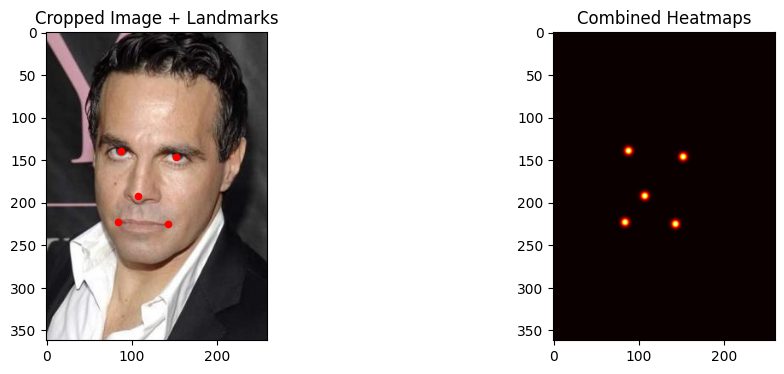

In [ ]:
import matplotlib.pyplot as plt
import cv2

sample_row = processed_landmarks_df_new.iloc[0]
img_name = sample_row['image_id']
img_path = os.path.join(output_dir, img_name)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

# извлекаем точки
landmarks = sample_row.drop('image_id').values.reshape(-1, 2)

# генерирую Heatmaps
hms = landmarks_to_heatmaps((h, w), landmarks, sigma=3)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Cropped Image + Landmarks")
plt.imshow(image_rgb)
plt.scatter(landmarks[:, 0], landmarks[:, 1], c='red', s=20)

plt.subplot(1, 2, 2)
plt.title("Combined Heatmaps")
plt.imshow(np.sum(hms, axis=0), cmap='hot')
plt.show()

вроде НОРМАЛЬНО все!

In [ ]:
import torch
import os
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CelebALandmarksDataset(Dataset):
    def __init__(self, img_dir, processed_landmarks_file, transform=None, heatmap_size=(64, 64), sigma=2):
        self.img_dir = img_dir
        self.transform = transform
        self.heatmap_size = heatmap_size
        self.sigma = sigma

        # загружаем уже пересчитанные координаты
        self.landmarks_df = pd.read_csv(processed_landmarks_file)
        self.image_names = self.landmarks_df['image_id'].tolist()

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # ззагрузка изображения
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        # получение координат (5 точек)
        row = self.landmarks_df.iloc[idx]
        # столбцы: image_id, le_x, le_y, re_x, re_y, nose_x, nose_y, lm_x, lm_y, rm_x, rm_y
        landmarks = row.drop('image_id').values.reshape(-1, 2).astype(np.float32)

        if self.transform:
            image = self.transform(image)

        # масштабируем точки под размер хитмапа (64x64)
        scale_x = self.heatmap_size[1] / orig_w
        scale_y = self.heatmap_size[0] / orig_h
        scaled_landmarks = landmarks * [scale_x, scale_y]

        # генерация таргета (N, 64, 64)
        heatmaps = landmarks_to_heatmaps(self.heatmap_size, scaled_landmarks, sigma=self.sigma)

        return image, torch.tensor(heatmaps, dtype=torch.float32)

# определяем транспформации
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# инициализируем Dataset
processed_landmarks_path = os.path.join(base_path, 'processed_landmarks.csv')
train_dataset = CelebALandmarksDataset(
    img_dir=output_dir,
    processed_landmarks_file=processed_landmarks_path,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Dataset ready: {len(train_dataset)} samples.")
# проверка одного батча
try:
    images, targets = next(iter(train_loader))
    print(f"Batch images shape: {images.shape}") # [16, 3, 256, 256]
    print(f"Batch targets shape: {targets.shape}") # [16, 5, 64, 64]
except Exception as e:
    print(f"Error loading batch: {e}")

Dataset ready: 10494 samples.
Batch images shape: torch.Size([16, 3, 256, 256])
Batch targets shape: torch.Size([16, 5, 64, 64])


In [ ]:
import torch.optim as optim
import os

# пути
base_path = '/content/drive/MyDrive/celeba_project'
output_dir = os.path.join(base_path, 'processed_dataset')
processed_landmarks_path = os.path.join(base_path, 'processed_landmarks.csv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# модель
model = StackedHourglass(
    num_stacks=2,
    num_keypoints=5,
    hourglass_channels=128,
    hourglass_depth=4
).to(device)

# функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# обучение
num_epochs = 10
save_path = os.path.join(base_path, 'stacked_hourglass_celeba_v2.pth')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Intermediate Supervision loss
        loss = sum([criterion(output, targets) for output in outputs])

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] completed. Avg Loss: {avg_loss:.4f}")

    # сохранение чекпоинта
    torch.save(model.state_dict(), save_path)

print(f"Training finished! Model saved to {save_path}")

Using device: cuda
Starting training...
Epoch [1/10], Step [50/656], Loss: 0.0299
Epoch [1/10], Step [100/656], Loss: 0.0150
Epoch [1/10], Step [150/656], Loss: 0.0107
Epoch [1/10], Step [200/656], Loss: 0.0090
Epoch [1/10], Step [250/656], Loss: 0.0084
Epoch [1/10], Step [300/656], Loss: 0.0077
Epoch [1/10], Step [350/656], Loss: 0.0073
Epoch [1/10], Step [400/656], Loss: 0.0067
Epoch [1/10], Step [450/656], Loss: 0.0064
Epoch [1/10], Step [500/656], Loss: 0.0064
Epoch [1/10], Step [550/656], Loss: 0.0059
Epoch [1/10], Step [600/656], Loss: 0.0060
Epoch [1/10], Step [650/656], Loss: 0.0056
Epoch [1/10] completed. Avg Loss: 0.0150
Epoch [2/10], Step [50/656], Loss: 0.0055
Epoch [2/10], Step [100/656], Loss: 0.0057
Epoch [2/10], Step [150/656], Loss: 0.0052
Epoch [2/10], Step [200/656], Loss: 0.0054
Epoch [2/10], Step [250/656], Loss: 0.0049
Epoch [2/10], Step [300/656], Loss: 0.0044
Epoch [2/10], Step [350/656], Loss: 0.0042
Epoch [2/10], Step [400/656], Loss: 0.0043
Epoch [2/10], Step

## Выравнивание по предсказанным точкам

Существует множество вариантов, как по полученным точкам правильно преобразовать картинку. Главное, что вам нужно понимать - **это задача классического компьютерного зрения** и решается при помощи математики, без нейронок. Вдаваться в подробности конкретных алгоритмов мы не будем.

Можно использовать аффинное преобразование, тогда потребуется только 3 точки, можно, например, искать матрицу гомографии, где может быть использовано больше точек, а может быть, есть еще что-то. Реализовывать эти алгоритмы самим не нужно. Достаточно провести небольшой ресерч и найти готовое решение (но **не готовую нейронку для выравнивания**), лишь бы оно работало. Количество используемых точек тоже выбирайте сами, подойдет любой вариант. Условный ориентир для поиска - библиотека **opencv**. Обязательно приведите примеры того, как работает ваш алгоритм.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


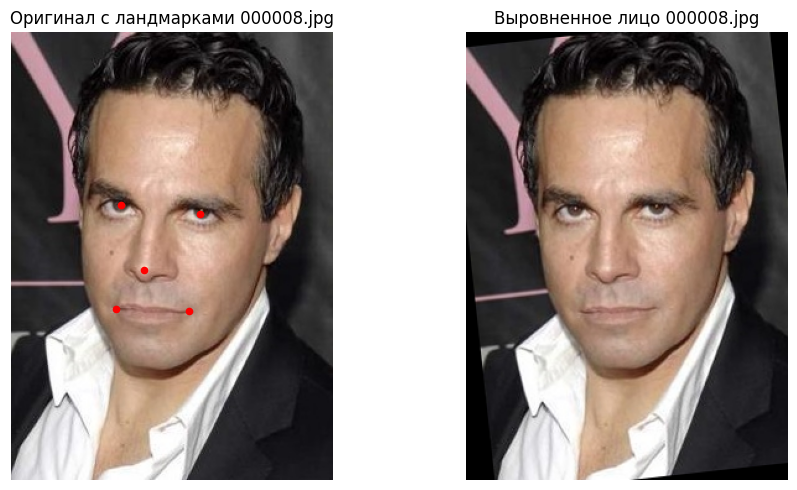

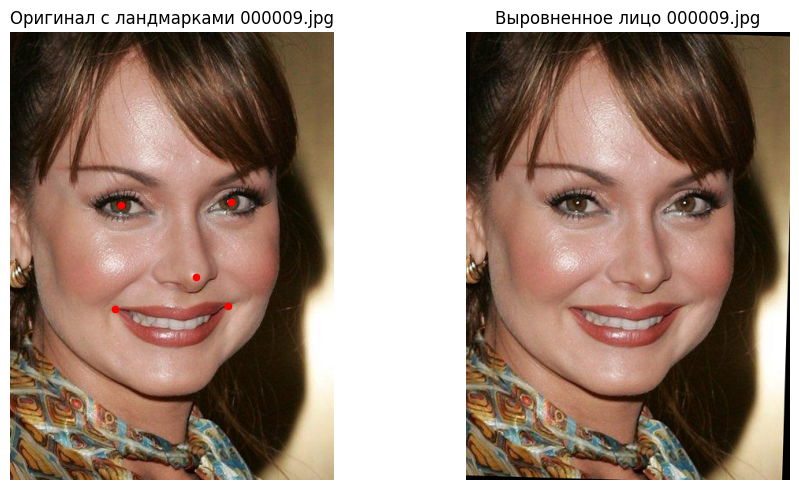

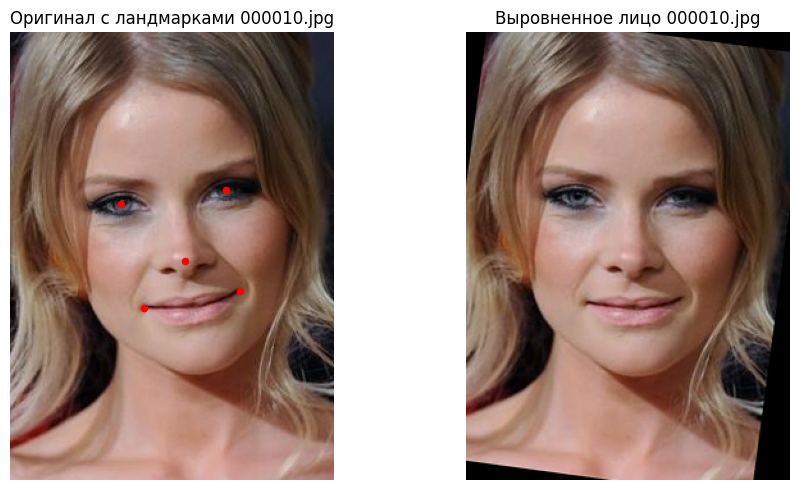

In [ ]:
def rotate_face_by_eyes(image, left_eye, right_eye): # поворот лица по глазам.

    # угол
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    # центр вращения - между глазами
    center = ((left_eye[0] + right_eye[0]) // 2,
              (left_eye[1] + right_eye[1]) // 2)

    # матрица поворота
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale=1.0)

    rotated = cv2.warpAffine(image, rotation_matrix,
                            (image.shape[1], image.shape[0]),
                            flags=cv2.INTER_CUBIC)
    return rotated

import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/celeba_project'
output_dir = os.path.join(base_path, 'processed_dataset')
processed_landmarks_path = os.path.join(base_path, 'processed_landmarks.csv')
processed_landmarks_df = pd.read_csv(processed_landmarks_path)

sample_rows_for_rotation_demo = [processed_landmarks_df.iloc[0], processed_landmarks_df.iloc[1], processed_landmarks_df.iloc[2]]

for i, sample_row in enumerate(sample_rows_for_rotation_demo):
    img_name = sample_row['image_id']
    img_path = os.path.join(output_dir, img_name)

    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    # Extract landmarks as a 5x2 array
    landmarks = sample_row[['le_x', 'le_y', 're_x', 're_y', 'nose_x', 'nose_y', 'lm_x', 'lm_y', 'rm_x', 'rm_y']].values.reshape(-1, 2).astype(np.float32)

    # Extract left and right eye for rotate_face_by_eyes
    left_eye = landmarks[0]
    right_eye = landmarks[1]

    # Perform face rotation using the simpler function
    rotated_image = rotate_face_by_eyes(image.copy(), left_eye, right_eye)

    # Convert to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rotated_image_rgb = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB)

    # Display the original and rotated images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title(f'Оригинал с ландмарками {img_name}')
    plt.imshow(image_rgb)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], c='red', s=20)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f'Выровненное лицо {img_name}')
    plt.imshow(rotated_image_rgb)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# План заданий

По итогу, в этом блоке у вас следующие задачи:

*   Подготовить датасет, сохранить файл с оригинальными названиями изображений
*   Реализовать Hourglass блок
*   Реализовать Stacked Hourglass
*   Преобразовать точки лица в Heatmap'ы
*   Обучить Stacked Hourglass
*   Найти функцию, которая по предсказанным ключевым точкам выравнивает лица на картинке (face alignment)
*   Подготовить датасет с кропнутыми и выровненными лицами для следующего этапа

**P.S. Не забывайте сохранять модели после обучения и выводите промежуточные результаты на экран**



Выравниваем весь наш отобранный и кропнутый датасет

In [ ]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from google.colab import drive
# drive.mount('/content/drive')
# пути
base_path = '/content/drive/MyDrive/celeba_project'
output_dir = os.path.join(base_path, 'processed_dataset')
processed_landmarks_path = os.path.join(base_path, 'processed_landmarks.csv')

aligned_output_dir = os.path.join(base_path, 'rotated_aligned_dataset') # Destination for aligned images
os.makedirs(aligned_output_dir, exist_ok=True)
processed_landmarks_df = pd.read_csv(processed_landmarks_path)

print(f"Starting rotation")
for index, row in tqdm(processed_landmarks_df.iterrows(), total=len(processed_landmarks_df)):
    img_name = row['image_id']
    img_path = os.path.join(output_dir, img_name)

    # проверка наличия
    if not os.path.exists(img_path):
        print(f"Warning: Image not found at {img_path}. Skipping.")
        continue

    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    landmarks = row[['le_x', 'le_y', 're_x', 're_y', 'nose_x', 'nose_y', 'lm_x', 'lm_y', 'rm_x', 'rm_y']].values.reshape(-1, 2).astype(np.float32)
    left_eye = landmarks[0]
    right_eye = landmarks[1]
    rotated_image = rotate_face_by_eyes(image.copy(), left_eye, right_eye)

    # сохраняем
    save_path = os.path.join(aligned_output_dir, img_name)
    cv2.imwrite(save_path, rotated_image)

print(f"Aligned images saved to {aligned_output_dir}")


**Удачи! У вас всё получится 💗!**

Вроде, получилось!
Выровненный датасет изображений сохранен в 'rotated_aligned_dataset'. Модель сохранена в 'stacked_hourglass_celeba_v2.pth'.
Выравнивает, вроде, нормально. Беспокоят только малость срезанные макушки и ушки - надо было, скорее всего, паддинг 20 % делать. Но жалко кучи потраченных gpuшных коллабовских лимитов машинного времени (да и моего тоже) - может прокатит...

In [ ]:
# НОВАЯ СТРАТЕГИЯ !

В общем - "дубль2". Добавляется принципиальный критерий отбора из "сырого" датасета - наличие нескольких изображений (фото) у одного уникального персонажа - это нужно для обучения распознавания во втором задании!

In [ ]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# пути
base_path = '/content/drive/MyDrive/celeba_project'
img_dir = os.path.join(base_path, 'raw_img/img_celeba')
attr_file = os.path.join(base_path, 'annotations/list_attr_celeba.txt')
bbox_file = os.path.join(base_path, 'annotations/list_bbox_celeba.txt')
identity_file = os.path.join(base_path, 'annotations/identity_CelebA.txt')

# новая папка для "отборного" датасета
output_dir_new = os.path.join(base_path, 'processed_dataset_NEW')
os.makedirs(output_dir_new, exist_ok=True)

# загружаем атрибуты, BBox и идентификаторы
attr_df = pd.read_csv(attr_file, sep=r'\s+', skiprows=1)
bbox_df = pd.read_csv(bbox_file, sep=r'\s+', skiprows=1)
identity_df = pd.read_csv(identity_file, sep=r'\s+', header=None, names=['image_id', 'person_id'])

if 'image_id' in bbox_df.columns:
    bbox_df.set_index('image_id', inplace=True)
identity_df.set_index('image_id', inplace=True)

# объединяем все данные и применяем фильтрацию по качеству и размеру (критерии как прошлый раз)
combined_df = attr_df.join(bbox_df).join(identity_df)

mask = (combined_df['Blurry'] == -1) & \
       (combined_df['width'] >= 64) & \
       (combined_df['height'] >= 64)

filtered_df = combined_df[mask].copy() # Use .copy() to avoid SettingWithCopyWarning

# новая стратегия отбора: приоритет людей с несколькими изображениями
min_images_per_person = 3 # минимальное количество изображений на человека для включения
target_total_images = 10500 # целевое общее количество изображений

# считаем количество изображений для каждого человека в отфильтрованном датасете
images_per_person_count = filtered_df.groupby('person_id').size().reset_index(name='image_count')

# отбираем только тех людей, у которых достаточно изображений
people_with_enough_images_df = images_per_person_count[images_per_person_count['image_count'] >= min_images_per_person]

# сортируем людей по убыванию количества изображений
people_with_enough_images_df = people_with_enough_images_df.sort_values(by='image_count', ascending=False)

final_selected_image_ids = []
current_total_images = 0

for _, row in people_with_enough_images_df.iterrows():
    person_id = row['person_id']
    num_images_for_person = row['image_count']

    if current_total_images + num_images_for_person <= target_total_images:
        # добавляем все изображения этого человека
        images_for_this_person = filtered_df[filtered_df['person_id'] == person_id].index.tolist()
        final_selected_image_ids.extend(images_for_this_person)
        current_total_images += num_images_for_person
    elif current_total_images < target_total_images:
        # если нужно "добрать" до target_total_images
        remaining_capacity = target_total_images - current_total_images
        images_for_this_person = filtered_df[filtered_df['person_id'] == person_id].index.tolist()
        final_selected_image_ids.extend(images_for_this_person[:remaining_capacity])
        current_total_images += len(images_for_this_person[:remaining_capacity])
    else:
        break # достигли целевого количества изображений

selected_images_list = final_selected_image_ids

print(f"Selected {len(selected_images_list)} images for the NEW dataset (target: {target_total_images} images).")
print(f"Number of unique people in NEW dataset: {filtered_df[filtered_df.index.isin(selected_images_list)]['person_id'].nunique()}")

processed_log = []
padding_ratio = 0.1

# кроп по BBox с паддингом
print(f"Cropping and saving images to {output_dir_new}")
for img_name in tqdm(selected_images_list):
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path):
        continue

    row_bbox = bbox_df.loc[img_name]
    x, y, w, h = int(row_bbox['x_1']), int(row_bbox['y_1']), int(row_bbox['width']), int(row_bbox['height'])

    img = cv2.imread(img_path)
    if img is None:
        continue
    img_h, img_w, _ = img.shape

    # расчет координат с паддингом
    pad_w = int(w * padding_ratio)
    pad_h = int(h * padding_ratio)

    x_1 = max(0, x - pad_w)
    y_1 = max(0, y - pad_h)
    x_2 = min(img_w, x + w + pad_w)
    y_2 = min(img_h, y + h + pad_h)

    face_crop = img[y_1:y_2, x_1:x_2]

    cv2.imwrite(os.path.join(output_dir_new, img_name), face_crop)
    processed_log.append(img_name)

# сохраняем список
log_df = pd.DataFrame(processed_log, columns=['image_id'])
selected_list_path_new = os.path.join(base_path, 'selected_images_list_NEW.csv') # new CSV name
log_df.to_csv(selected_list_path_new, index=False)

print(f"Done! NEW dataset saved to {output_dir_new}")
print(f"Selected image list saved to {selected_list_path_new}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selected 10500 images for the NEW dataset (target: 10500 images).
Number of unique people in NEW dataset: 350
Cropping and saving images to /content/drive/MyDrive/celeba_project/processed_dataset_NEW...


100%|██████████| 10500/10500 [04:51<00:00, 35.96it/s]

Done! NEW dataset saved to /content/drive/MyDrive/celeba_project/processed_dataset_NEW
Selected image list saved to /content/drive/MyDrive/celeba_project/selected_images_list_NEW.csv


Для выравнивания буду использовать ту же функцию что и раньше - rotate_face_by_eyes. Выведем еще раз несколько выровненных изображений и начнем равнять наш новый "отборный" датасет

Demonstrating face alignment on a few images from the NEW dataset...


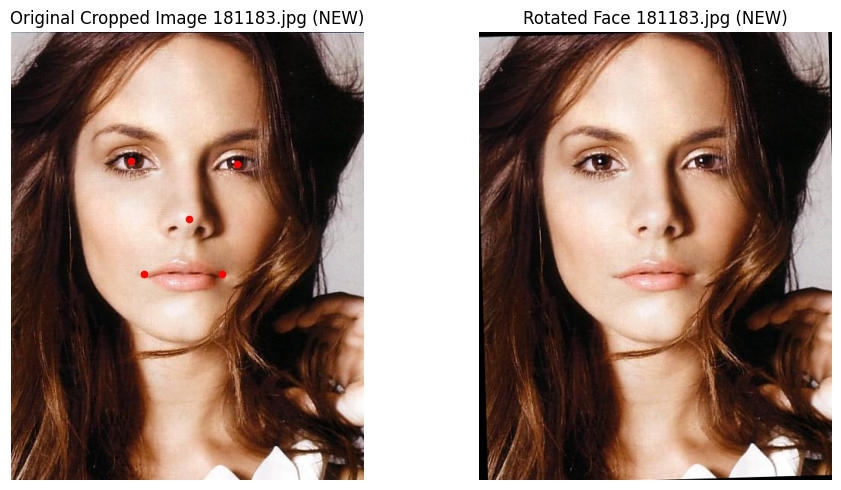

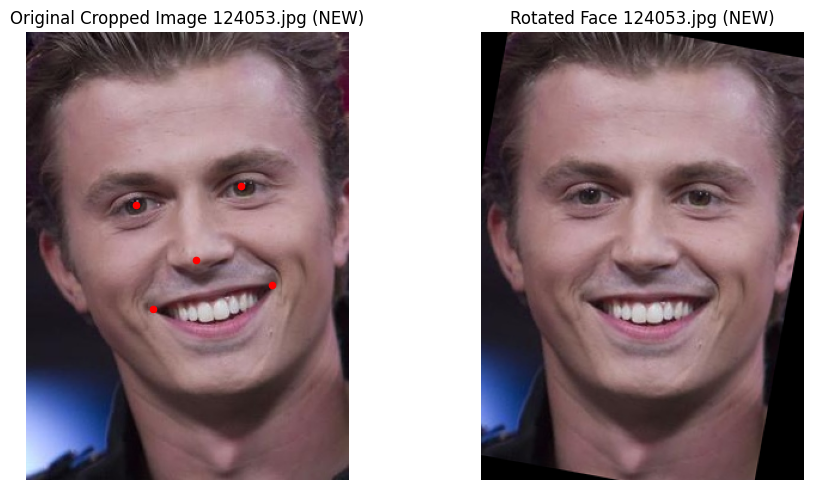

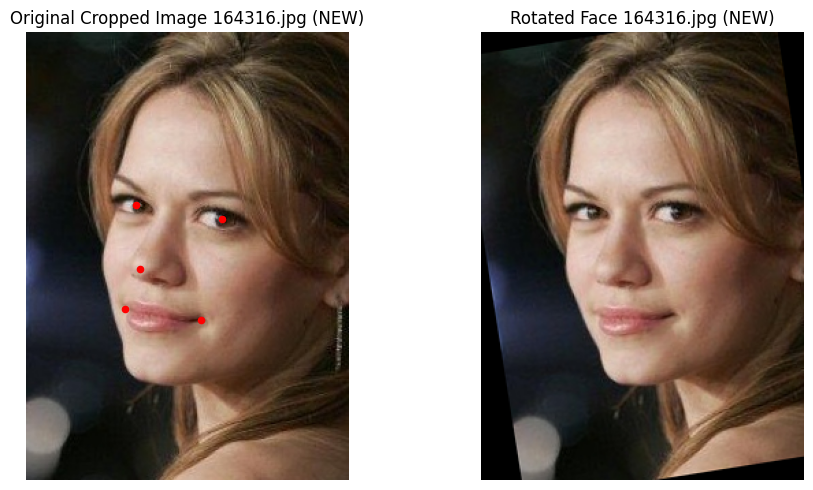

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

# пути
base_path = '/content/drive/MyDrive/celeba_project'
output_dir_new = os.path.join(base_path, 'processed_dataset_NEW')
processed_landmarks_path_new = os.path.join(base_path, 'processed_landmarks_NEW.csv')
aligned_output_dir_new = os.path.join(base_path, 'rotated_aligned_dataset_NEW')

processed_landmarks_df_new = pd.read_csv(processed_landmarks_path_new)

print("Demonstrating face alignment on a few images from the NEW dataset...")

# выберем 3 случайных фотки
sample_rows = processed_landmarks_df_new.sample(n=3, random_state=42)

for index, sample_row in sample_rows.iterrows():
    img_name = sample_row['image_id']
    img_path = os.path.join(output_dir_new, img_name)

    image = cv2.imread(img_path)
    if image is None:
        continue

    landmarks = sample_row[['le_x', 'le_y', 're_x', 're_y', 'nose_x', 'nose_y', 'lm_x', 'lm_y', 'rm_x', 'rm_y']].values.reshape(-1, 2).astype(np.float32)
    left_eye = landmarks[0]
    right_eye = landmarks[1]
    rotated_image = rotate_face_by_eyes(image.copy(), left_eye, right_eye)

    # конвертируем для matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rotated_image_rgb = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title(f'Original Cropped Image {img_name} (NEW)')
    plt.imshow(image_rgb)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], c='red', s=20)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f'Rotated Face {img_name} (NEW)')
    plt.imshow(rotated_image_rgb)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

base_path = '/content/drive/MyDrive/celeba_project'
output_dir_new = os.path.join(base_path, 'processed_dataset_NEW')
processed_landmarks_path_new = os.path.join(base_path, 'processed_landmarks_NEW.csv')
aligned_output_dir_new = os.path.join(base_path, 'rotated_aligned_dataset_NEW')

os.makedirs(aligned_output_dir_new, exist_ok=True)

if 'processed_landmarks_df_new' not in locals() or processed_landmarks_df_new is None:
    processed_landmarks_df_new = pd.read_csv(processed_landmarks_path_new)

print(f"Starting rotation alignment of {len(processed_landmarks_df_new)} images from {output_dir_new}")

for index, row in tqdm(processed_landmarks_df_new.iterrows(), total=len(processed_landmarks_df_new)):
    img_name = row['image_id']
    img_path = os.path.join(output_dir_new, img_name)

    # проверка наличия
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    landmarks = row[['le_x', 'le_y', 're_x', 're_y', 'nose_x', 'nose_y', 'lm_x', 'lm_y', 'rm_x', 'rm_y']].values.reshape(-1, 2).astype(np.float32)
    left_eye = landmarks[0]
    right_eye = landmarks[1]
    rotated_image = rotate_face_by_eyes(image.copy(), left_eye, right_eye)

    # сохраняем
    save_path = os.path.join(aligned_output_dir_new, img_name)
    cv2.imwrite(save_path, rotated_image)

print(f"Rotation alignment complete! Aligned images saved to {aligned_output_dir_new}")

Starting rotation alignment of 10500 images from /content/drive/MyDrive/celeba_project/processed_dataset_NEW...


100%|██████████| 10500/10500 [06:35<00:00, 26.55it/s]

Rotation alignment complete! Aligned images saved to /content/drive/MyDrive/celeba_project/rotated_aligned_dataset_NEW


Выровненный датасет сохранен в celeba_project/rotated_aligned_dataset_NEW